# Data Preparation for Machine Learning: A Beginner's Guide

In [ ]:
import pandas as pd
import numpy as np

# We can load the Titanic dataset directly from a common data science library called seaborn
import seaborn as sns
titanic_df = sns.load_dataset('titanic')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Let's look at the first few rows of our data to understand what it looks like.
display(titanic_df.head())

## 1. Basic Data Cleaning: Understanding Your Data

Before we do anything fancy, it's crucial to understand what kind of data we have and if anything is missing or doesn't look right. We need to check:

*   **What columns (features) do we have?** (e.g., 'age', 'sex', 'fare')
*   **What type of data is in each column?** (e.g., numbers, text, dates)
*   **Are there any missing pieces of information?** This is called 'missing data'.

In [ ]:
# Let's get a summary of our dataset. This will show us column names, how many non-missing values there are, and the data type.
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


From the `.info()` output, we can see:

*   **`Age`**: Has 714 non-null values, meaning 891 - 714 = 177 values are missing.
*   **`Cabin`**: Has only 204 non-null values, meaning a lot of values are missing.
*   **`Embarked`**: Has 889 non-null values, meaning 2 values are missing.

### Handling Missing Values

Missing values are like blank spots in our data. Machine learning models usually don't know how to handle these blanks, so we need to fill them in or remove them. Here are common strategies:

1.  **Drop (remove) rows or columns**: If a column has too many missing values (like `Cabin`), it might be best to remove it entirely. If only a few rows have missing data, we can remove those rows.
2.  **Impute (fill in) values**: We can fill missing values with a sensible guess, such as:
    *   The **average (mean)** or **middle (median)** value for numbers.
    *   The **most frequent (mode)** value for categories (like 'male'/'female').

In [ ]:
# Let's check the number of missing values for each column more clearly
print("Missing values before handling:")
display(titanic_df.isnull().sum())

# Strategy 1: Drop columns with too many missing values or that are redundant.
# The 'deck' column has many missing values. 'embark_town' is redundant with 'embarked'.
# 'alone' is derived from 'sibsp' and 'parch', so we can also drop it for simplicity.
# Note: 'cabin' was likely a typo as the column is named 'deck' in this dataset.
# Using 'errors="ignore"' to prevent KeyError if columns are already dropped.
titanic_df = titanic_df.drop(columns=['deck', 'embark_town', 'alone'], errors='ignore')

# Strategy 2: Fill missing 'Age' values with the median age.
# The median is often better than the mean if there are extreme ages (outliers).
# Addressing FutureWarning: assign the result back to the column.
titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].median())

# Strategy 3: Fill missing 'Embarked' values with the most frequent port.
most_frequent_embarked = titanic_df['embarked'].mode()[0]
# Addressing FutureWarning: assign the result back to the column.
titanic_df['embarked'] = titanic_df['embarked'].fillna(most_frequent_embarked)

print("\nMissing values after handling:")
display(titanic_df.isnull().sum())

# Display the first few rows again to see the changes
print("\nDataFrame after handling missing values:")
display(titanic_df.head())

Missing values before handling:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0



Missing values after handling:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0



DataFrame after handling missing values:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no


## 2. Outlier Detection and Removal

**Outliers** are data points that are very different from the other data points. Imagine if most people on the Titanic paid a fare around $30, but one person paid $5000. That $5000 would be an outlier. Outliers can sometimes skew our model's understanding.

We can often spot outliers using plots like **box plots** or by looking at the data's distribution. For now, we'll demonstrate a simple way to identify some extreme outliers and optionally remove them, though often capping them is preferred in real-world scenarios.

For this example, we'll look at the 'fare' column.

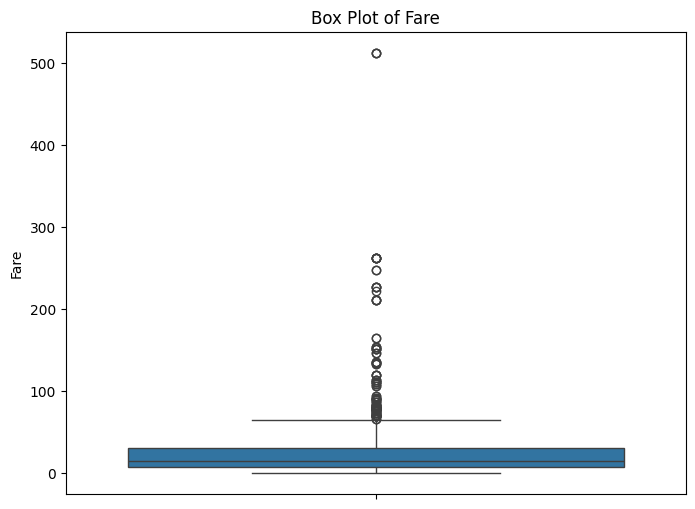

Number of fare outliers detected: 116
Original DataFrame shape: (891, 12)
DataFrame shape after outlier removal: (775, 12)


In [ ]:
# Let's visualize the 'fare' distribution using a box plot to see outliers.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(y=titanic_df['fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')
plt.show()

# We can also use a statistical method. For example, using the Interquartile Range (IQR).
# IQR is the range between the 25th percentile (Q1) and 75th percentile (Q3) of the data.
# Outliers are often defined as values that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

Q1 = titanic_df['fare'].quantile(0.25)
Q3 = titanic_df['fare'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Count outliers
outliers = titanic_df[(titanic_df['fare'] < lower_bound) | (titanic_df['fare'] > upper_bound)]
print(f"Number of fare outliers detected: {len(outliers)}")

# For demonstration, let's remove these outliers. In a real project, you might choose to cap them instead.
# This means setting very high values to the upper bound and very low values to the lower bound.
titanic_df_no_outliers = titanic_df[~((titanic_df['fare'] < lower_bound) | (titanic_df['fare'] > upper_bound))]

print(f"Original DataFrame shape: {titanic_df.shape}")
print(f"DataFrame shape after outlier removal: {titanic_df_no_outliers.shape}")

# We'll continue with the dataframe where outliers are removed for the next steps.
titanic_df = titanic_df_no_outliers.copy()

## 3. Encoding Categorical Variables

**Categorical variables** are features that represent categories, not numbers. Examples include 'sex' (male/female) or 'embarked' (S/C/Q for port of embarkation). Machine learning models primarily work with numbers, so we need to convert these categories into numerical representations.

There are two main ways to encode categorical variables:

1.  **One-Hot Encoding (for Nominal Categories)**: Use this when the categories have no natural order (e.g., 'red', 'blue', 'green' - none is 'better' than the other). It creates new columns for each category, with 1 if the value is that category and 0 otherwise.
2.  **Label Encoding (for Ordinal Categories)**: Use this when categories *do* have an order (e.g., 'small', 'medium', 'large'). It assigns a unique number to each category (e.g., small=0, medium=1, large=2).

In our Titanic dataset:
*   `sex` (male/female) is nominal.
*   `embarked` (S/C/Q) is nominal.
*   `pclass` (1st, 2nd, 3rd) is somewhat ordinal (higher class is better), but often treated as nominal too. We will treat it as nominal here for simplicity and to demonstrate one-hot encoding.

In [ ]:
# Let's identify the categorical columns we need to encode
categorical_cols = ['sex', 'embarked', 'pclass']

print("Original DataFrame columns:", titanic_df.columns.tolist())

# Use One-Hot Encoding for 'sex', 'embarked', and 'pclass'
# `pd.get_dummies` is a great function for this.
titanic_df_encoded = pd.get_dummies(titanic_df, columns=categorical_cols, drop_first=True)
# `drop_first=True` avoids multicollinearity, which is a more advanced topic but generally good practice.

print("\nDataFrame columns after One-Hot Encoding:", titanic_df_encoded.columns.tolist())

# Display the first few rows of the new DataFrame to see the changes
print("\nDataFrame after encoding categorical variables:")
display(titanic_df_encoded.head())

Original DataFrame columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive']

DataFrame columns after One-Hot Encoding: ['survived', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alive', 'sex_male', 'embarked_Q', 'embarked_S', 'pclass_2', 'pclass_3']

DataFrame after encoding categorical variables:


,survived,age,sibsp,parch,fare,class,who,adult_male,alive,sex_male,embarked_Q,embarked_S,pclass_2,pclass_3
0,0,22.0,1,0,7.2500,Third,man,True,no,True,False,True,False,True
2,1,26.0,0,0,7.9250,Third,woman,False,yes,False,False,True,False,True
3,1,35.0,1,0,53.1000,First,woman,False,yes,False,False,True,False,False
4,0,35.0,0,0,8.0500,Third,man,True,no,True,False,True,False,True
5,0,28.0,0,0,8.4583,Third,man,True,no,True,True,False,False,True


Notice how 'sex' has been replaced by 'sex_male', 'embarked' by 'embarked_Q' and 'embarked_S', and 'pclass' by 'pclass_2' and 'pclass_3'. If 'sex_male' is 1, it means the passenger is male; if 0, they are female. Similarly for the other new columns.

## 4. Feature Scaling

**Feature scaling** is a technique to standardize the range of independent features or variables. Why do we need this? Imagine two features: 'age' (ranging from 0 to 80) and 'fare' (ranging from 0 to 500+).

Many machine learning algorithms calculate the distance between data points. If 'fare' has much larger values than 'age', the 'fare' feature might dominate the distance calculation, making the model pay less attention to 'age'. Scaling brings all features to a similar range.

Common scaling methods:

1.  **Standardization (Z-score normalization)**: Transforms data to have a mean of 0 and a standard deviation of 1. Good for algorithms that assume a Gaussian (bell-shaped) distribution.
2.  **Normalization (Min-Max scaling)**: Scales data to a fixed range, usually 0 to 1. Good for algorithms that are sensitive to the range of data, like neural networks.

We'll apply standardization to our numerical features like 'age', 'fare', 'sibsp', and 'parch'.

In [ ]:
# We need a library called `scikit-learn` for scaling.
from sklearn.preprocessing import StandardScaler

# Identify numerical columns that need scaling
# We exclude 'survived' because it's our target variable (what we want to predict), not a feature.
# We also exclude the dummy variables created earlier as they are already 0 or 1.

numerical_cols = ['age', 'sibsp', 'parch', 'fare']

# Create a StandardScaler object
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
titanic_df_encoded[numerical_cols] = scaler.fit_transform(titanic_df_encoded[numerical_cols])

print("\nDataFrame after feature scaling (first 5 rows of scaled numerical columns):")
display(titanic_df_encoded[numerical_cols].head())

# Display the entire DataFrame head to show all changes
print("\nFull DataFrame head after all transformations:")
display(titanic_df_encoded.head())


DataFrame after feature scaling (first 5 rows of scaled numerical columns):


,age,sibsp,parch,fare
0,-0.528321,0.625606,-0.433718,-0.779117
2,-0.215182,-0.486423,-0.433718,-0.729373
3,0.489381,0.625606,-0.433718,2.599828
4,0.489381,-0.486423,-0.433718,-0.720161
5,-0.058613,-0.486423,-0.433718,-0.690071



Full DataFrame head after all transformations:


,survived,age,sibsp,parch,fare,class,who,adult_male,alive,sex_male,embarked_Q,embarked_S,pclass_2,pclass_3
0,0,-0.528321,0.625606,-0.433718,-0.779117,Third,man,True,no,True,False,True,False,True
2,1,-0.215182,-0.486423,-0.433718,-0.729373,Third,woman,False,yes,False,False,True,False,True
3,1,0.489381,0.625606,-0.433718,2.599828,First,woman,False,yes,False,False,True,False,False
4,0,0.489381,-0.486423,-0.433718,-0.720161,Third,man,True,no,True,False,True,False,True
5,0,-0.058613,-0.486423,-0.433718,-0.690071,Third,man,True,no,True,True,False,False,True


Notice how the values in 'age', 'sibsp', 'parch', and 'fare' are now centered around 0, with many values being negative. This is what `StandardScaler` does!

## 5. Feature Selection

**Feature selection** is the process of choosing the most relevant features (columns) from your dataset to train your machine learning model. Why is this important?

*   **Reduces complexity**: Fewer features mean a simpler model, which is easier to understand and train.
*   **Prevents overfitting**: Too many irrelevant features can make a model learn noise instead of the actual patterns.
*   **Improves performance**: Models can often perform better with only the most informative features.
*   **Reduces training time**: Less data means faster training.

There are many ways to select features. A simple method is to look at the **correlation** between each feature and our target variable ('survived'). Correlation tells us how strongly two variables are related. A strong positive or negative correlation suggests a feature might be important.

In [ ]:
# Our target variable is 'survived'. Let's see how each feature correlates with 'survived'.
# We'll drop the 'who' column as it's very similar to 'sex' and 'adult_male'.
# Also drop 'class' and 'alone' as we've created 'pclass_X' and `alone` was dropped earlier.

# Create a copy to avoid modifying the original dataframe when dropping columns for correlation calculation
df_for_selection = titanic_df_encoded.drop(columns=['who', 'class'], errors='ignore')

# Calculate the correlation matrix
correlation_matrix = df_for_selection.corr(numeric_only=True)

# Display correlations with the 'survived' column
print("Correlation of each feature with 'survived':")
display(correlation_matrix['survived'].sort_values(ascending=False))

# Based on this, we can decide to keep features with a high absolute correlation.
# For example, let's keep features with an absolute correlation greater than 0.1.

# Identify features to keep based on correlation threshold
# We exclude 'survived' itself from the features to select
selected_features = correlation_matrix['survived'][abs(correlation_matrix['survived']) > 0.1].index.tolist()
selected_features.remove('survived') # Remove the target itself from the feature list

print(f"\nFeatures selected based on correlation (> 0.1 absolute value): {selected_features}")

# Create a new DataFrame with only the selected features and the target variable
titanic_df_final = titanic_df_encoded[selected_features + ['survived']]

print("\nFinal DataFrame with selected features (first 5 rows):")
display(titanic_df_final.head())

Correlation of each feature with 'survived':


,survived
survived,1.000000
fare,0.234422
pclass_2,0.169769
parch,0.098575
embarked_Q,0.032707
sibsp,-0.003156
embarked_S,-0.102337
age,-0.118009
pclass_3,-0.254634
sex_male,-0.499888



Features selected based on correlation (> 0.1 absolute value): ['age', 'fare', 'adult_male', 'sex_male', 'embarked_S', 'pclass_2', 'pclass_3']

Final DataFrame with selected features (first 5 rows):


,age,fare,adult_male,sex_male,embarked_S,pclass_2,pclass_3,survived
0,-0.528321,-0.779117,True,True,True,False,True,0
2,-0.215182,-0.729373,False,False,True,False,True,1
3,0.489381,2.599828,False,False,True,False,False,1
4,0.489381,-0.720161,True,True,True,False,True,0
5,-0.058613,-0.690071,True,True,False,False,True,0


## 6. Dimensionality Reduction

**Dimensionality Reduction** is a technique to reduce the number of features (or dimensions) in your dataset while trying to preserve as much of the important information as possible. It's different from feature selection because instead of picking a subset of existing features, it creates new, fewer features that are combinations of the original ones.

Why use dimensionality reduction?

*   **Overcoming the 'curse of dimensionality'**: As the number of features increases, the data becomes very sparse, and models can struggle to find meaningful patterns.
*   **Visualization**: It can be hard to visualize data with many features. Reducing dimensions to 2 or 3 allows us to plot and understand the data better.
*   **Faster training**: Fewer features mean faster computation.
*   **Reduced noise**: It can help remove redundant or noisy features.

One popular technique is **Principal Component Analysis (PCA)**. PCA transforms the data into a new set of dimensions (called Principal Components) that capture the most variance (information) in the data.

In [ ]:
# We'll use `scikit-learn` again for PCA.
from sklearn.decomposition import PCA

# For dimensionality reduction, we usually apply it to the features, not the target variable.
# Let's separate features (X) and target (y).
X = titanic_df_final.drop(columns=['survived'])
y = titanic_df_final['survived']

# Initialize PCA to reduce to 2 components for easy visualization
pca = PCA(n_components=2)

# Fit PCA on our features and transform them
X_pca = pca.fit_transform(X)

# Create a new DataFrame with the principal components
df_pca = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])

# Add the target variable back for potential visualization later
df_pca = pd.concat([df_pca, y.reset_index(drop=True)], axis = 1)

print("\nDataFrame after Dimensionality Reduction (PCA):")
display(df_pca.head())

# You can also check how much variance each component explains
print(f"\nExplained variance by each principal component: {pca.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")

# For subsequent steps, we would typically use X_pca or df_pca as our new feature set.


DataFrame after Dimensionality Reduction (PCA):


,principal_component_1,principal_component_2,survived
0,-1.006060,0.282788,0
1,-0.781413,0.032445,1
2,2.334946,-1.559842,1
3,-0.320696,0.979063,0
4,-0.668883,0.547981,0



Explained variance by each principal component: [0.38292966 0.32309929]
Total explained variance by 2 components: 0.71


And there you have it! Your data is now cleaned, handled for missing values and outliers, transformed, scaled, and features have been selected. This prepared data (`titanic_df_final`) is now ready to be used for training a machine learning model. Each of these steps is crucial for building effective and robust models.